Imports & Setup

In [8]:
# ================================================
# Random Forest - Airline Customer Satisfaction
# ================================================

!pip install pandas seaborn scikit-learn matplotlib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


Load Dataset

In [9]:
from google.colab import files
print("📤 Please upload 'Invistico_Airline.csv'")
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
print(f"✅ Dataset loaded! Shape: {df.shape}")

📤 Please upload 'Invistico_Airline.csv'


Saving Invistico_Airline.csv to Invistico_Airline (3).csv
✅ Dataset loaded! Shape: (129880, 22)


Preprocessing & Encoding

In [11]:
# Preprocessing
df_clean = df.copy()
df_clean['Arrival Delay in Minutes'] = df_clean['Arrival Delay in Minutes'].fillna(
    df_clean['Arrival Delay in Minutes'].median()
)

# One-hot encoding for categorical features
categorical_cols = ['Customer Type', 'Type of Travel', 'Class'] # 'Gender' removed as it's not in the DataFrame
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Encode target
le = LabelEncoder()
df_encoded['satisfaction'] = le.fit_transform(df_encoded['satisfaction'])

print("✅ Preprocessing completed!")
print("Target classes:", le.classes_)

✅ Preprocessing completed!
Target classes: ['dissatisfied' 'satisfied']


Three-Way Split (Train / Validation / Test)

In [12]:
X = df_encoded.drop(columns=['satisfaction'])
y = df_encoded['satisfaction']

# Split 1: Train+Val vs Test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Split 2: Train vs Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"Train shape      : {X_train.shape}")
print(f"Validation shape : {X_val.shape}")
print(f"Test shape       : {X_test.shape}")

Train shape      : (77928, 22)
Validation shape : (25976, 22)
Test shape       : (25976, 22)


GridSearchCV with PredefinedSplit

In [13]:
# Combine Train + Validation
X_train_val_combined = pd.concat([X_train, X_val])
y_train_val_combined = pd.concat([y_train, y_val])

# PredefinedSplit
test_fold = np.concatenate([np.full(len(X_train), -1), np.full(len(X_val), 0)])
ps = PredefinedSplit(test_fold)

# Parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=ps,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("🔄 Starting Grid Search...")
grid_search.fit(X_train_val_combined, y_train_val_combined)

print("\n✅ Best Parameters:", grid_search.best_params_)
print("Best CV F1-Score:", round(grid_search.best_score_, 4))

🔄 Starting Grid Search...
Fitting 1 folds for each of 24 candidates, totalling 24 fits

✅ Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV F1-Score: 0.9596


Final Model Evaluation on Test Se

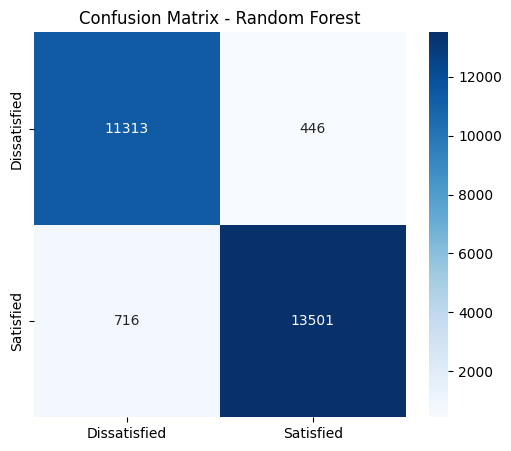

=== Test Set Performance ===
              precision    recall  f1-score   support

Dissatisfied       0.94      0.96      0.95     11759
   Satisfied       0.97      0.95      0.96     14217

    accuracy                           0.96     25976
   macro avg       0.95      0.96      0.95     25976
weighted avg       0.96      0.96      0.96     25976


Accuracy : 0.9553
Precision: 0.9680
Recall   : 0.9496
F1-Score : 0.9587


In [14]:
# Final Model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.title('Confusion Matrix - Random Forest')
plt.show()

# Metrics
print("=== Test Set Performance ===")
print(classification_report(y_test, y_pred, target_names=['Dissatisfied', 'Satisfied']))

print(f"\nAccuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")

Feature Importance & Business Summary

=== Top 10 Most Important Features ===
                            Feature  Importance
7            Inflight entertainment    0.226476
2                      Seat comfort    0.134116
9            Ease of Online booking    0.070749
8                    Online support    0.063755
11                 Leg room service    0.044905
4                    Food and drink    0.044855
10                 On-board service    0.041515
1                   Flight Distance    0.039209
18  Customer Type_disloyal Customer    0.039125
15                  Online boarding    0.035225


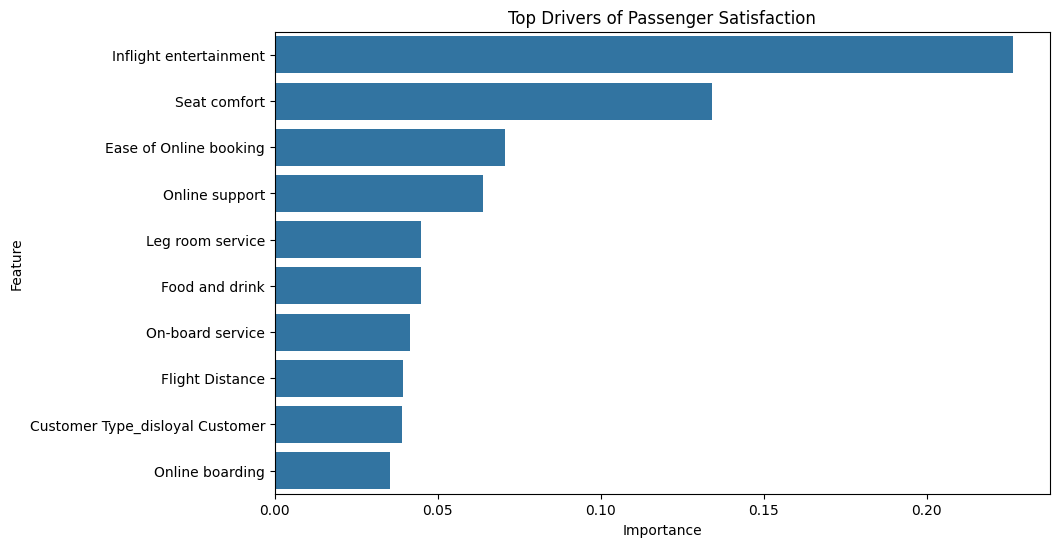


💼 EXECUTIVE SUMMARY
Random Forest significantly reduces overfitting compared to a single Decision Tree.
Recommended actions: Improve In-flight Wi-Fi, Seat Comfort, Entertainment, and Cleanliness.
Recommendation: Deploy Random Forest for more reliable predictions.


In [15]:
# Top Features
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("=== Top 10 Most Important Features ===")
print(importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(10), x='Importance', y='Feature')
plt.title('Top Drivers of Passenger Satisfaction')
plt.show()

print("\n💼 EXECUTIVE SUMMARY")
print("Random Forest significantly reduces overfitting compared to a single Decision Tree.")
print("Recommended actions: Improve In-flight Wi-Fi, Seat Comfort, Entertainment, and Cleanliness.")
print("Recommendation: Deploy Random Forest for more reliable predictions.")